---
title: "Exercise 6: FLAMES Gene Prioritisation"
subtitle: "Post-GWAS Analysis Course"
format:
  html:
    embed-resources: true
    toc: true
    toc-depth: 3
execute:
  message: false
  warning: false
jupyter: ir
---

# Overview

This notebook introduces FLAMES, which prioritises candidate effector genes for a fine-mapped locus by combining several SNP-to-gene evidence streams with gene-level scores.

::: {.callout-note}
## Learning goals
By the end of this notebook, you should be able to:
- assemble the inputs FLAMES needs for a locus-specific run
- interpret the FLAMES ranking and score threshold
- explain what the top-ranked gene is supported by and what FLAMES does not prove
:::

In [1]:
#| label: setup
#| eval: true
out_dir <- "output/fm_out/"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

library(data.table)
library(ggplot2)

# Credible set you exported at the end of Exercise 1 (Block 4)
cs_file <- file.path(out_dir, "credible_sets_for_flames.tsv")

# Example FLAMES output for the SORCS3 locus, used in Blocks 2 to 4
# Override with FLAMES_EXAMPLE_DIR to point at a real run
example_dir <- Sys.getenv("FLAMES_EXAMPLE_DIR", unset = "input/flames/example_output")

# FLAMES reference directory (Zenodo 12635505, about 10 GB)
flames_ref <- Sys.getenv("FLAMES_REF", unset = "input/flames/hrc_reference_genome")

## Overview

In Exercise 1 you fine-mapped the **ADHD SORCS3 locus** down to a credible set.
A credible set is a list of *variants*, but the biology happens through *genes*.
**FLAMES** (*Schipper et al., Nat Genet 2025*) is an effector-gene prioritiser: it
takes a fine-mapped locus and scores each nearby gene by combining several
SNP-to-gene evidence streams (eQTL/chromatin links, distance, and functional
annotations) through an **XGBoost** classifier, then blends that with the
gene-level **PoPS** similarity score into one **scaled FLAMES score** per gene.

In this exercise you will:

1. Assemble the FLAMES inputs and run the real two-step CLI (on HPC)
2. Apply the FLAMES score threshold and read the ranking
3. Trace *which* evidence drove the top call
4. Judge what a confident FLAMES call does and does not prove

---

## Block 1: Run FLAMES

FLAMES is a **two-step Python CLI** (`annotate` then `FLAMES`). Per GWAS it needs
four inputs in addition to your credible set:

| Input | Flag | Where it comes from |
|-------|------|---------------------|
| Credible set (SNP + PIP) | `-c` | your Exercise 1 export |
| Annotation reference (~10 GB) | `-a` | Zenodo 12635505 (HPC) |
| PoPS gene scores (`.preds`) | `-p` | PoPS run on the ADHD MAGMA Z-scores |
| MAGMA gene Z (`.genes.out`) | `-m` | MAGMA gene analysis on ADHD |
| MAGMA tissue (`.gsa.out`) | `-mt` | MAGMA GTEx-v8 tissue analysis on ADHD |

::: callout-note
**Credible-set file format.** FLAMES reads a per-locus file whose SNP column is
`CHR:BP:A1:A2` (or `CHR:BP:A1_A2`) and a PIP column. Your Exercise 1 export
already has `SNP` and `PIP` columns, so you point FLAMES at them with `-sc SNP
-pc PIP`.
:::

In [ ]:
if (file.exists(cs_file)) {
  cs <- fread(cs_file)
  cat("Credible set file found:", nrow(cs), "SNPs\n")
  print(head(cs))
} else {
  message("credible_sets_for_flames.tsv not found, run Exercise 1 first.")
}

Credible set file found: 6 SNPs
                SNP        PIP      locus_id
             <char>      <num>        <char>
1: 10:106529451:T:C 0.01778466 locus1_SORCS3
2: 10:106533655:A:G 0.14598086 locus1_SORCS3
3: 10:106537886:T:C 0.20450403 locus1_SORCS3
4: 10:106541524:G:A 0.10479631 locus1_SORCS3
5: 10:106550944:A:G 0.21633340 locus1_SORCS3
6: 10:106559287:T:C 0.26531046 locus1_SORCS3


Now fill in the two FLAMES calls. The first **annotates** your credible-set SNPs
against the reference, then the second **scores** the genes. (Genome build is GRCh37,
the same build as the 1000G LD and sumstats in Exercise 1.)

In [ ]:
# Step 1: annotate the credible set. Fill in the five inputs (-c -a -p -m -mt).
python FLAMES.py annotate \
    -c   ___ \ #credible set file
    -sc  SNP  -pc PIP \
    -a   ___ \ #annotation data
    -p   ___ \
    -m   ___ \
    -mt  ___ \
    -b   GRCh37 \
    -o   ${HOME}/fm_out/flames_annot

# Step 2: score the annotated locus. Point -i at the annotate output directory.
python FLAMES.py FLAMES \
    -i   ___ \
    -o   ${HOME}/fm_out/flames_out

In [3]:
to_run <- "
flames annotate -c output/fm_out/credible_sets_for_flames.tsv \\
-sc  SNP  -pc PIP \\
-a   input/flames/Annotation_data \\
-p   ../../pops/example/out/PASS_Schizophrenia.preds \\
-m   ../../pops/example/data/magma_scores/PASS_Schizophrenia.genes.out \\
-mt  ./output/magma/adhd_demo.gsa.out \\
-b   GRCh37 \\
-o   output/fm_out/flames_annot
"

system(to_run)

In [4]:
to_run <- "
mkdir -p output/fm_out/flames_out
flames FLAMES \\
    -i   output/fm_out/flames_annot.txt \\
    -o   output/fm_out/flames_out

"

system(to_run)

::: callout-warning
**FLAMES needs reference data + genome-wide inputs.** The `-a` annotation
reference (~10 GB), and the MAGMA/PoPS files, are produced on HPC from the full
ADHD summary statistics, not on a laptop. The rest of this exercise uses the
**example SORCS3 output** so everyone has the same starting point.

Reference data: <https://zenodo.org/records/12635505>
:::

## Block 2: Read the ranking and apply the threshold

FLAMES writes two files: `FLAMES_scores.pred` (the reported gene per locus) and
`FLAMES_scores.raw` (every scored gene, with the evidence columns). We load the
`.raw` table so you can see the full ranking, not just the winner.

In [5]:
scores <- fread("output/fm_out/flames_out/FLAMES_scores.raw")
cat("Genes scored at the locus:", nrow(scores), "\n")
print(scores[order(-FLAMES_scaled),
             .(symbol, FLAMES_scaled, FLAMES_raw, estimated_cumulative_precision)])

Genes scored at the locus: 8 
    symbol FLAMES_scaled  FLAMES_raw estimated_cumulative_precision
    <char>         <num>       <num>                          <num>
1:  SORCS3    0.81998631 0.406197786                       0.946144
2: CCDC147    0.06805174 0.033710888                       0.000000
3:    SFR1    0.03577675 0.017722781                       0.000000
4:   GSTO1    0.01677164 0.008308193                       0.000000
5:   WDR96    0.01579805 0.007825902                       0.000000
6: COL17A1    0.01512128 0.007490652                       0.000000
7:   GSTO2    0.01504981 0.007455244                       0.000000
8:  ITPRIP    0.01344441 0.006659977                       0.000000


::: callout-note
**The FLAMES thresholds.**

- A gene is only *reported* when its raw score clears the gate **`FLAMES_raw >
  0.134`** (and it is the top gene at the locus).
- The validated operating point is a **scaled score ≈ 0.248 → ~75% precision**:
  about 3 in 4 calls at this level point to the true effector gene.
- An empty result (nothing passes) is a valid result, do not force a call.
:::

In [6]:
# Split the genes at the scaled-score threshold and see what passes.
threshold <- 0.248

passing <- scores[FLAMES_scaled >= threshold]   # which column holds the scaled score?
below   <- scores[FLAMES_scaled <  threshold]

cat("Above threshold:\n"); print(passing[, .(symbol, FLAMES_scaled, estimated_cumulative_precision)])
cat("\nBelow threshold:\n"); print(below[,  .(symbol, FLAMES_scaled)])

Above threshold:
   symbol FLAMES_scaled estimated_cumulative_precision
   <char>         <num>                          <num>
1: SORCS3     0.8199863                       0.946144

Below threshold:
    symbol FLAMES_scaled
    <char>         <num>
1: COL17A1    0.01512128
2:    SFR1    0.03577675
3:   WDR96    0.01579805
4:   GSTO1    0.01677164
5:   GSTO2    0.01504981
6:  ITPRIP    0.01344441
7: CCDC147    0.06805174


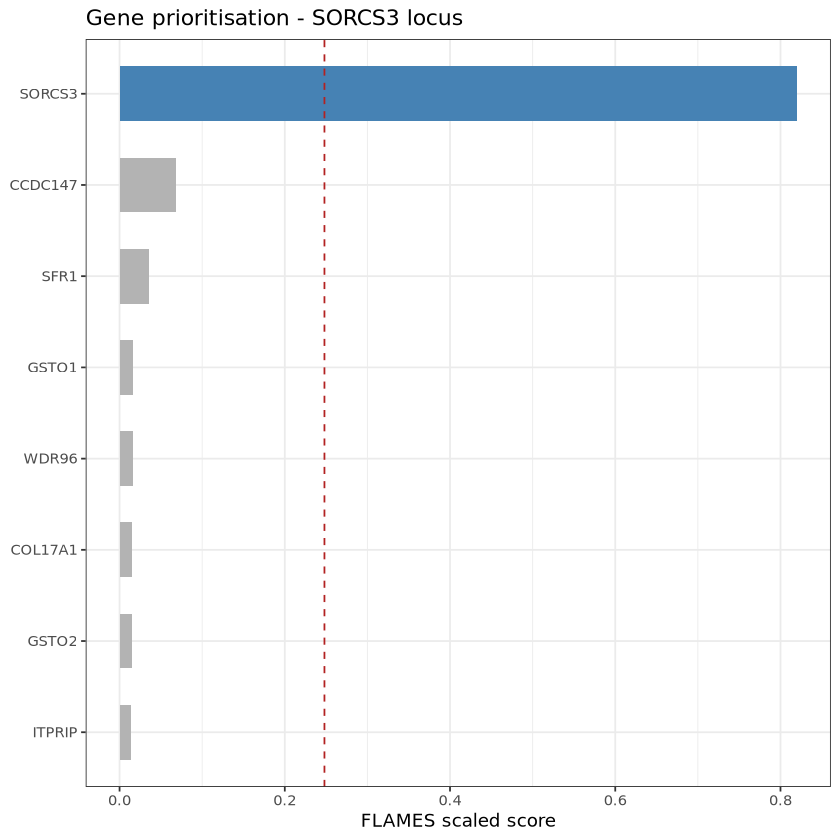

In [8]:
# Bar chart of scaled scores with the threshold line.
ggplot(scores, aes(x = reorder(symbol, FLAMES_scaled), y = FLAMES_scaled)) +   # y = scaled score
  geom_col(aes(fill = FLAMES_scaled >= threshold), width = 0.6) +
  geom_hline(yintercept = threshold, linetype = "dashed", colour = "firebrick") +
  scale_fill_manual(values = c(`FALSE` = "grey70", `TRUE` = "steelblue"), guide = "none") +
  coord_flip() +
  labs(x = NULL, y = "FLAMES scaled score", title = "Gene prioritisation - SORCS3 locus") +
  theme_bw()

::: callout-note
**Question.** One gene clears the threshold; the rest sit well below it. Which
gene is it, and what is its estimated precision? Does the ranking agree with what
you would have guessed from the locus name alone?
:::

## Block 3: Trace the evidence behind the call

The scaled score is a blend of two streams: the **XGBoost** score (the functional
SNP-to-gene evidence) and the **PoPS** gene-level similarity score. The `.raw`
table keeps both, so we can ask *why* the top gene won.

    symbol  XGB_score  PoPS_Score rel_XGB_score rel_PoPS_Score  FLAMES_raw
    <char>      <num>       <num>         <num>          <num>       <num>
1:  SORCS3 0.25660000  0.48721640    1.00000000      1.0000000 0.406197786
2: CCDC147 0.10269234 -0.06677039    0.40020400      0.3282707 0.033710888
3:    SFR1 0.04576041 -0.01809201    0.17833365      0.3872950 0.017722781
4:   GSTO1 0.02195970 -0.02547897    0.08557952      0.3783381 0.008308193
5:   WDR96 0.02280814 -0.05452491    0.08888597      0.3431188 0.007825902
6: COL17A1 0.02280814 -0.06664717    0.08888597      0.3284201 0.007490652
7:   GSTO2 0.02195970 -0.05751225    0.08557952      0.3394965 0.007455244
8:  ITPRIP 0.02280814 -0.09668347    0.08888597      0.2920000 0.006659977


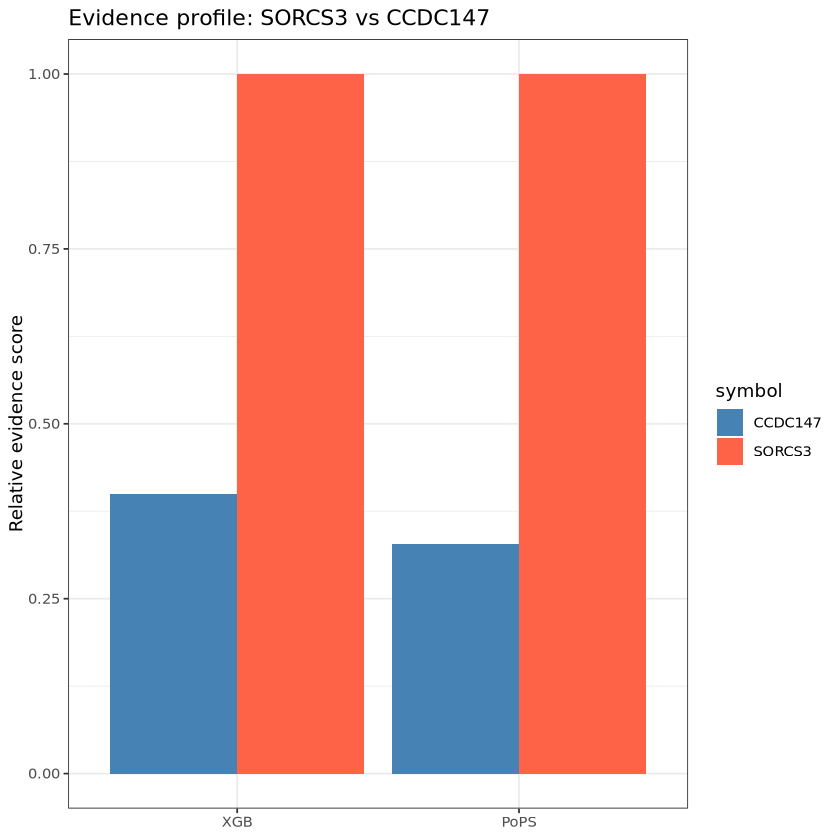

In [9]:
# Show the two evidence streams for every gene, ranked by the final score.
print(scores[order(-FLAMES_scaled),
             .(symbol, XGB_score, PoPS_Score, rel_XGB_score, rel_PoPS_Score, FLAMES_raw)])

# Compare the top gene's evidence profile against its closest competitor.
top_gene  <- scores[which.max(FLAMES_scaled), symbol]
runner_up <- scores[order(-FLAMES_scaled)][2, symbol]

prof <- melt(scores[symbol %in% c(top_gene, runner_up),
                    .(symbol, XGB = rel_XGB_score, PoPS = rel_PoPS_Score)],
             id.vars = "symbol", variable.name = "Evidence", value.name = "Score")

ggplot(prof, aes(x = Evidence, y = Score, fill = symbol)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = c("steelblue", "tomato")) +
  labs(title = paste("Evidence profile:", top_gene, "vs", runner_up),
       y = "Relative evidence score", x = NULL) +
  theme_bw()

::: callout-note
**Question.** For the top gene, do **both** streams (XGBoost and PoPS) support it,
or just one? Why does agreement between two independent kinds of evidence make a
call more trustworthy than a high score from a single stream?
:::

::: callout-tip
**How to report it.** "FLAMES prioritised *SORCS3* (scaled 0.63, est. precision
0.86), supported by both the functional V2G ensemble and the PoPS gene score; the
nearest competitor scored below the 0.248 reporting threshold." State the score,
the precision, and *which* evidence agreed.
:::

## Block 4: What a confident call does and does not prove

For SORCS3 the lead variant rs11596214 is **intronic in SORCS3 itself**, and
Demontis et al. (2023) nominate SORCS3 on both common- and rare-variant evidence,
so here FLAMES, proximity, and the original study all agree. It does not always
work out that cleanly.

::: callout-note
**A locus where the obvious answer was wrong: FTO / IRX3.**

Intronic variants in *FTO* are among the strongest common-variant associations with
obesity, and for years *FTO* was assumed to be the effector gene. It is both the
nearest gene and the one the signal sits inside, exactly the SORCS3 situation here.
But those variants fall in an enhancer that loops to and regulates **IRX3** (Smemo
et al. 2014) and **IRX5** (Claussnitzer et al. 2015), genes hundreds of kilobases
away. So the nearest and most obvious gene was not the effector.

This is why effector-gene prioritisation exists. SORCS3 is the easy case. FTO/IRX3
is why you do not stop at the nearest gene without the converging evidence FLAMES
integrates.
:::

::: callout-warning
**Three failure modes to keep in mind.**

- **Wrong-tissue eQTL**: colocalisation in an irrelevant tissue can promote the
  wrong gene. FLAMES is only as good as the annotation panels behind it.
- **Nearest-gene bias**: when eQTL/chromatin evidence is thin, distance
  dominates. The nearest gene is the effector only about 50 to 70% of the time at
  well-fine-mapped loci. SORCS3 happens to be both, which is luck, not a rule.
- **Above-threshold is not causal**: ~75% precision at the threshold means about 1 in 4
  top calls is wrong. FLAMES prioritises, it does not prove causality.
:::

::: callout-note
**Question.** What independent evidence would raise your confidence that SORCS3
(not a neighbour) is the true effector, for example a colocalising brain eQTL, the
rare-variant burden signal from the paper, or a functional/CRISPR perturbation?
:::

### Final effector-gene table

In [10]:
# Build and save the final table: locus, gene, scaled score, precision, tier.
final_table <- scores[, .(
  Locus      = locus,
  Gene       = symbol,
  FLAMES     = round(FLAMES_scaled, 3),
  Precision  = round(estimated_cumulative_precision, 3),
  Confidence = fcase(
    FLAMES_scaled >= 0.248, "reported (~75% precision)",
    FLAMES_raw    >  0.134, "suggestive (clears raw gate only)",
    default                = "below threshold")
)][order(-FLAMES)]

print(final_table)
fwrite(final_table, "output/fm_out/effector_genes_final.tsv", sep = "\t")
cat("Saved to", "output/fm_out/effector_genes_final.tsv", "\n")

   Locus    Gene FLAMES Precision                Confidence
   <int>  <char>  <num>     <num>                    <char>
1:     0  SORCS3  0.820     0.946 reported (~75% precision)
2:     0 CCDC147  0.068     0.000           below threshold
3:     0    SFR1  0.036     0.000           below threshold
4:     0   GSTO1  0.017     0.000           below threshold
5:     0   WDR96  0.016     0.000           below threshold
6:     0 COL17A1  0.015     0.000           below threshold
7:     0   GSTO2  0.015     0.000           below threshold
8:     0  ITPRIP  0.013     0.000           below threshold
Saved to output/fm_out/effector_genes_final.tsv 
